## **Build a Linear Regression Model to Predict ELO Based on Historical Match Results**

---

#### **Import data from Snowflake**

In [1]:
from sqlalchemy import create_engine
import pandas as pd
from dotenv import load_dotenv
import os 

load_dotenv()

USERNAME = os.getenv("USERNAME")
PASSWORD = os.getenv("PASSWORD")
ACCOUNT = os.getenv("ACCOUNT")
WAREHOUSE = os.getenv("WAREHOUSE")
DATABASE = os.getenv("DATABASE")
SCHEMA = os.getenv("SCHEMA")
ROLE = "ACCOUNTADMIN"

# Snowflake connection
engine = create_engine(
    f"snowflake://{USERNAME}:{PASSWORD}@{ACCOUNT}/{DATABASE}/{SCHEMA}?warehouse={WAREHOUSE}&role={ROLE}"
)

query = "SELECT * FROM GAMES" 

with engine.connect() as conn:
    df = pd.read_sql(query, conn)

# Remove duplicates
df.drop_duplicates(inplace=True, keep="first")

# Print samples
df.head(5)

,white_username,white_elo,white_result,white_accuracy,black_username,black_elo,black_result,black_accuracy,time_control,time_class,date_time,rated,opening
0,MagnusCarlsen,3234,timevsinsufficient,84,Lembke407,3202,timevsinsufficient,82,180,blitz,2025-02-04,true,Nimzo Indian Defense Three Knights Duchamp Var...
1,Lembke407,3211,win,93,MagnusCarlsen,3225,resigned,84,180,blitz,2025-02-04,true,Queens Gambit Accepted Classical Main Line
2,MagnusCarlsen,3233,win,93,Lembke407,3203,resigned,90,180,blitz,2025-02-04,true,Ruy Lopez Opening Morphy Defense Anderssen Var...
3,Lembke407,3196,resigned,90,MagnusCarlsen,3240,win,94,180,blitz,2025-02-04,true,Kings Indian Defense Orthodox Positional Defen...
4,MagnusCarlsen,3247,win,88,Lembke407,3189,resigned,81,180,blitz,2025-02-04,true,Sicilian Defense Nyezhmetdinov Rossolimo Attac...


In [2]:
# Print DF length
print(len(df))

13008


#### **Features Extraction**

In [3]:
import numpy as np

# Change here if want to see other player stats (enter username)
name = "MagnusCarlsen"

elo = df.loc[
    (df["white_username"] == name) | (df["black_username"] == name)
].copy()

elo["elo"] = np.where(
    elo["white_username"] == name,
    elo["white_elo"],
    elo["black_elo"]
)

elo = elo[["date_time", "elo", "time_class"]]

# We only care about the last ELO of each day
elo = elo.groupby(["time_class", "date_time"])["elo"].last().reset_index()

# Convert to datetime
elo["date_time"] = pd.to_datetime(elo["date_time"])

# View DataFrame
elo.head(5)

,time_class,date_time,elo
0,blitz,2025-01-03,3279
1,blitz,2025-01-05,3280
2,blitz,2025-01-07,3251
3,blitz,2025-01-08,3251
4,blitz,2025-01-09,3284


#### **Visualization**

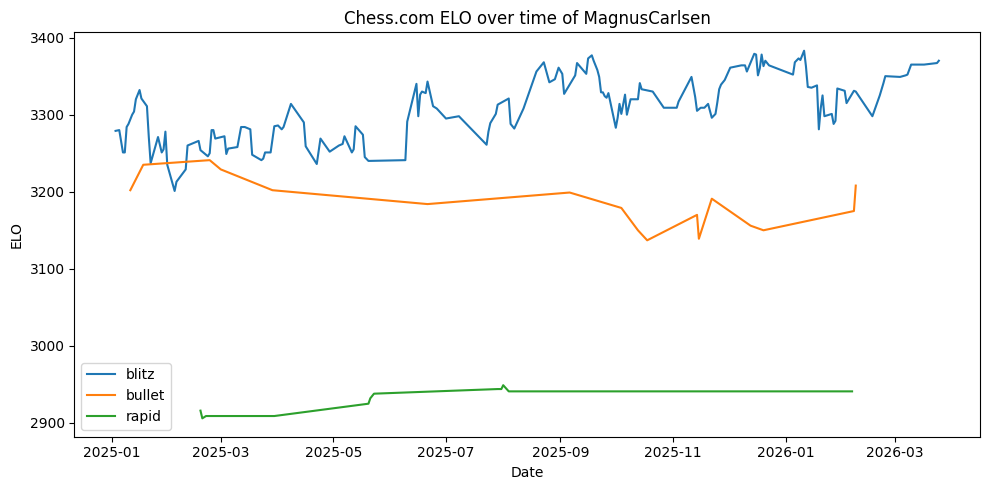

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot 3 line for 3 time class
for key, group in elo.groupby("time_class"):
    plt.plot(group["date_time"], group["elo"], label=key)

plt.xlabel("Date")
plt.ylabel("ELO")
plt.title(f"Chess.com ELO over time of {name}")

plt.legend()
plt.tight_layout()
plt.show()

#### **Building models**

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, unix_timestamp
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

# Init SparkSession
spark = SparkSession.builder \
    .appName(f"ELO prediction for {name}") \
    .getOrCreate()

# Create feature vector
assembler = VectorAssembler(
    inputCols=["timestamp_scaled"],
    outputCol="features"
)

models = {}

for key, group in elo.groupby("time_class"):
    # Convert to Spark DataFrame
    spark_df = spark.createDataFrame(group)

    # Convert datetime to numeric 
    spark_df = spark_df.withColumn("timestamp", unix_timestamp(col("date_time")))
    min_time = spark_df.selectExpr("min(timestamp)").first()[0]
    
    spark_df = spark_df.withColumn(
        "timestamp_scaled",
        (col("timestamp") - min_time) / 86400 # Convert from second to day
    )

    data = assembler.transform(spark_df).select("features", col("elo").alias("label"))

    lr = LinearRegression(featuresCol="features", labelCol="label", regParam=0.1)
    model = lr.fit(data)

    # Append model to dict
    models[key] = model

    print(f"Model for {key}")
    print("Intercept:", model.intercept)
    print("Coefficient:", model.coefficients)
    print("-"*50 + "\n")

your 131072x1 screen size is bogus. expect trouble
26/03/27 13:05:29 WARN Utils: Your hostname, DESKTOP-ABGKMNK resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/27 13:05:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/27 13:05:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/27 13:05:46 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/27 13:05:46 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/03/27 13:05:46 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Model for blitz
Intercept: 3261.2178926358133
Coefficient: [0.21803719745475303]
--------------------------------------------------



Model for bullet
Intercept: 3221.629753443781
Coefficient: [-0.16377461966867465]
--------------------------------------------------



Model for rapid
Intercept: 2916.1362128329006
Coefficient: [0.12066624981579667]
--------------------------------------------------



#### **Prediction**

In [8]:
from pyspark.sql import Row
from pyspark.ml.feature import VectorAssembler

# Input time class and number of days since 1/2025 (approximately)
time_classes = ["bullet", "blitz", "rapid"]
day_number = 300

for time_class in time_classes:
    if time_class not in models:
        print(f"No model for {time_class}")
    else:
        model = models[time_class]

        # Create feature vector and predict
        test_df = spark.createDataFrame([Row(timestamp_scaled=day_number)])
        test_df = VectorAssembler(inputCols=["timestamp_scaled"], outputCol="features").transform(test_df)
        prediction = model.transform(test_df).collect()[0]["prediction"]
        print(f"Time class: {time_class}, number of days: {day_number} => Predicted ELO: {int(prediction)}")

Time class: bullet, number of days: 300 => Predicted ELO: 3172
Time class: blitz, number of days: 300 => Predicted ELO: 3326
Time class: rapid, number of days: 300 => Predicted ELO: 2952
